# 3. Physical slot-time allocation

This notebook reproduces the physical limit substitution, the fixed E300/D80 diagnostic, and the two candidate-selection profiles.

For each propagation time, the empirical-p90 propagation fit determines one data limit and the remaining portion of a nine-second budget determines one execution limit. Every target pair at that split is evaluated against the same physical limits.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
for path in (SRC_DIR, SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = DATA_DIR / "7999"
PLOTS_DIR = PROJECT_ROOT / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

REFRESH_FROM_NETWORK = (
    os.environ.get("REFRESH_7999_SIMULATION_FROM_NETWORK", "0") == "1"
)
REUSE_OUTPUTS = os.environ.get("REUSE_7999_SIMULATION_OUTPUTS", "0") == "1"

def run_script(script: str, *args: str) -> None:
    command = [sys.executable, str(SCRIPTS_DIR / script), *map(str, args)]
    print("+", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

print("project root:", PROJECT_ROOT)
print("network refresh:", REFRESH_FROM_NETWORK)
print("reuse generated outputs:", REUSE_OUTPUTS)

project root: /Users/william/PycharmProjects/eip-7999-research
network refresh: False
reuse generated outputs: True


## Run the physical target surfaces

The mainnet benchmark used by the historically anchored rule is refreshed directly from Xatu when REFRESH_7999_SIMULATION_FROM_NETWORK=1. Otherwise the notebook uses the existing ignored benchmark export.

In [2]:
import run_slot_time_scenarios
import build_historical_fee_market_benchmark
import summarize_slot_time_candidates

slot_surface_path = OUT_DIR / "slot_time_scenarios.csv"
if not REUSE_OUTPUTS:
    run_slot_time_scenarios.main()
elif not slot_surface_path.exists():
    raise FileNotFoundError(
        f"{slot_surface_path.relative_to(PROJECT_ROOT)} does not exist; rerun "
        "without REUSE_7999_SIMULATION_OUTPUTS=1"
    )

benchmark_path = OUT_DIR / "historical_fee_market_benchmark.csv"
if REFRESH_FROM_NETWORK:
    build_historical_fee_market_benchmark.main()
elif not benchmark_path.exists():
    raise FileNotFoundError(
        f"{benchmark_path.relative_to(PROJECT_ROOT)} is absent. Set "
        "REFRESH_7999_SIMULATION_FROM_NETWORK=1 to query the benchmark from Xatu."
    )

summarize_slot_time_candidates.main()

12 rows -> data/7999/slot_time_guardrail_frontier.csv
6 rows -> data/7999/slot_time_guardrail_candidates.csv
4 rows -> data/7999/slot_time_e300_d80_marginal_tradeoffs.csv
55 rows -> data/7999/slot_time_historical_benchmark_admissible.csv
5 rows -> data/7999/slot_time_historical_benchmark_frontier.csv
5 rows -> data/7999/slot_time_maximum_throughput.csv
6 missing tier/split pairs -> data/7999/slot_time_guardrail_missing_splits.csv


## Physical limits and the E300/D80 mechanism diagnostic

The propagation fit gives an 89.909M data limit at 3.0 seconds. The report rounds that limit to 90M and uses the exact E300/D80 cell from Notebook 2 for the published 3.0-second row. The diagnostic below retains the fitted physical row, shows the small rounding difference explicitly, and then constructs the report table from the exact 90M reference plus the fitted 3.5–5.0-second rows.

In [3]:
slot_surface = pd.read_csv(slot_surface_path)
slot_surface = slot_surface[slot_surface["propagation_time_s"] >= 3.0]
limits = (
    slot_surface[[
        "propagation_time_s", "execution_time_s", "execution_limit", "data_limit"
    ]]
    .drop_duplicates()
    .sort_values("propagation_time_s")
)
limits["execution_limit_M"] = limits["execution_limit"] / 1e6
limits["data_limit_M"] = limits["data_limit"] / 1e6
display(limits[[
    "propagation_time_s", "execution_time_s", "execution_limit_M", "data_limit_M"
]])

physical_fixed = slot_surface[
    np.isclose(slot_surface["execution_target"], 300e6)
    & np.isclose(slot_surface["data_target"], 80e6)
].copy().sort_values("propagation_time_s")

exact_grid = pd.read_csv(OUT_DIR / "design_surface.csv")
exact_grid = exact_grid[
    np.isclose(exact_grid["execution_target"], 300e6)
    & np.isclose(exact_grid["data_target"], 80e6)
].iloc[0]

metric_columns = [
    "data_fee_wei", "static_data_offered", "bal_execution_data_offered",
    "bal_state_data_offered", "included_execution", "execution_fill",
    "data_limit_hit_fraction", "execution_limit_hit_fraction",
    "execution_floor_bounded_fraction",
]
report_fixed = physical_fixed.copy()
at_three_seconds = report_fixed["propagation_time_s"].eq(3.0)
for column in metric_columns:
    report_fixed.loc[at_three_seconds, column] = exact_grid[column]
report_fixed.loc[at_three_seconds, "data_limit"] = 90e6

for frame in (physical_fixed, report_fixed):
    frame["demanded_data_M"] = (
        frame["static_data_offered"]
        + frame["bal_execution_data_offered"]
        + frame["bal_state_data_offered"]
    ) / 1e6
    frame["delivered_execution_M"] = frame["included_execution"] / 1e6

rounding_comparison = pd.DataFrame({
    "series": ["fitted physical limit", "published 90M reference"],
    "data_limit_M": [
        physical_fixed.loc[at_three_seconds, "data_limit"].iloc[0] / 1e6,
        90.0,
    ],
    "demanded_data_M": [
        physical_fixed.loc[at_three_seconds, "demanded_data_M"].iloc[0],
        report_fixed.loc[at_three_seconds, "demanded_data_M"].iloc[0],
    ],
})
display(rounding_comparison)

display(
    report_fixed[[
        "propagation_time_s", "execution_limit", "data_limit", "data_fee_wei",
        "demanded_data_M", "delivered_execution_M", "execution_fill",
        "data_limit_hit_fraction", "execution_limit_hit_fraction",
        "execution_floor_bounded_fraction",
    ]]
)

assert np.isclose(
    report_fixed.loc[at_three_seconds, "demanded_data_M"].iloc[0],
    119.5,
    atol=0.06,
)
assert report_fixed.loc[
    report_fixed["included_execution"].idxmax(), "propagation_time_s"
] == 4.5

,propagation_time_s,execution_time_s,execution_limit_M,data_limit_M
42,3.0,6.0,600.0,89.908576
98,3.5,5.5,550.0,108.400672
168,4.0,5.0,500.0,126.892784
252,4.5,4.5,450.0,145.384880
350,5.0,4.0,400.0,163.876976


,series,data_limit_M,demanded_data_M
0,fitted physical limit,89.908576,119.717192
1,published 90M reference,90.000000,119.481446


,propagation_time_s,execution_limit,data_limit,data_fee_wei,demanded_data_M,delivered_execution_M,execution_fill,data_limit_hit_fraction,execution_limit_hit_fraction,execution_floor_bounded_fraction
97,3.0,600000000.0,90000000.0,5.053779,119.481446,226.395140,0.754650,0.592117,0.000827,0.835224
165,3.5,550000000.0,108400672.0,18.534924,95.553256,261.887374,0.872958,0.283908,0.005848,0.619640
247,4.0,500000000.0,126892784.0,44.462658,87.874281,270.740794,0.902469,0.154704,0.023238,0.561513
343,4.5,450000000.0,145384880.0,56.761076,84.780777,271.857575,0.906192,0.085500,0.069386,0.558873
441,5.0,400000000.0,163876976.0,61.030734,83.497094,268.502192,0.895007,0.049846,0.138242,0.581136


## Candidate configurations and report figures

The maximum-throughput profile selects the highest mean delivered execution at each split. The historically anchored lower-pressure profile applies the published near-limit and target-deviation ceilings plus the preliminary interior-equilibrium eligibility check.

,propagation_time_s,configuration,delivered_execution_M,execution_floor_bounded_fraction,any_near_limit_fraction
0,3.0,E300/D67.5,252.928839,0.687298,0.321355
1,3.5,E300/D77,263.797685,0.609510,0.265301
2,4.0,E300/D80,270.740794,0.561513,0.188175
3,4.5,E300/D90,272.597538,0.542900,0.206467
4,5.0,E300/D90,271.035838,0.556003,0.230191


,propagation_time_s,configuration,delivered_execution_M,execution_floor_bounded_fraction,any_near_limit_fraction
0,3.0,E175/D36,173.643713,0.047292,0.019206
1,3.5,E225/D52.5,221.415128,0.128301,0.052116
2,4.0,E225/D60,223.003595,0.068424,0.053387
3,4.5,E225/D60,222.966285,0.069065,0.051598
4,5.0,E200/D67.5,199.673886,0.013382,0.054547


wrote 5 figures to plots/


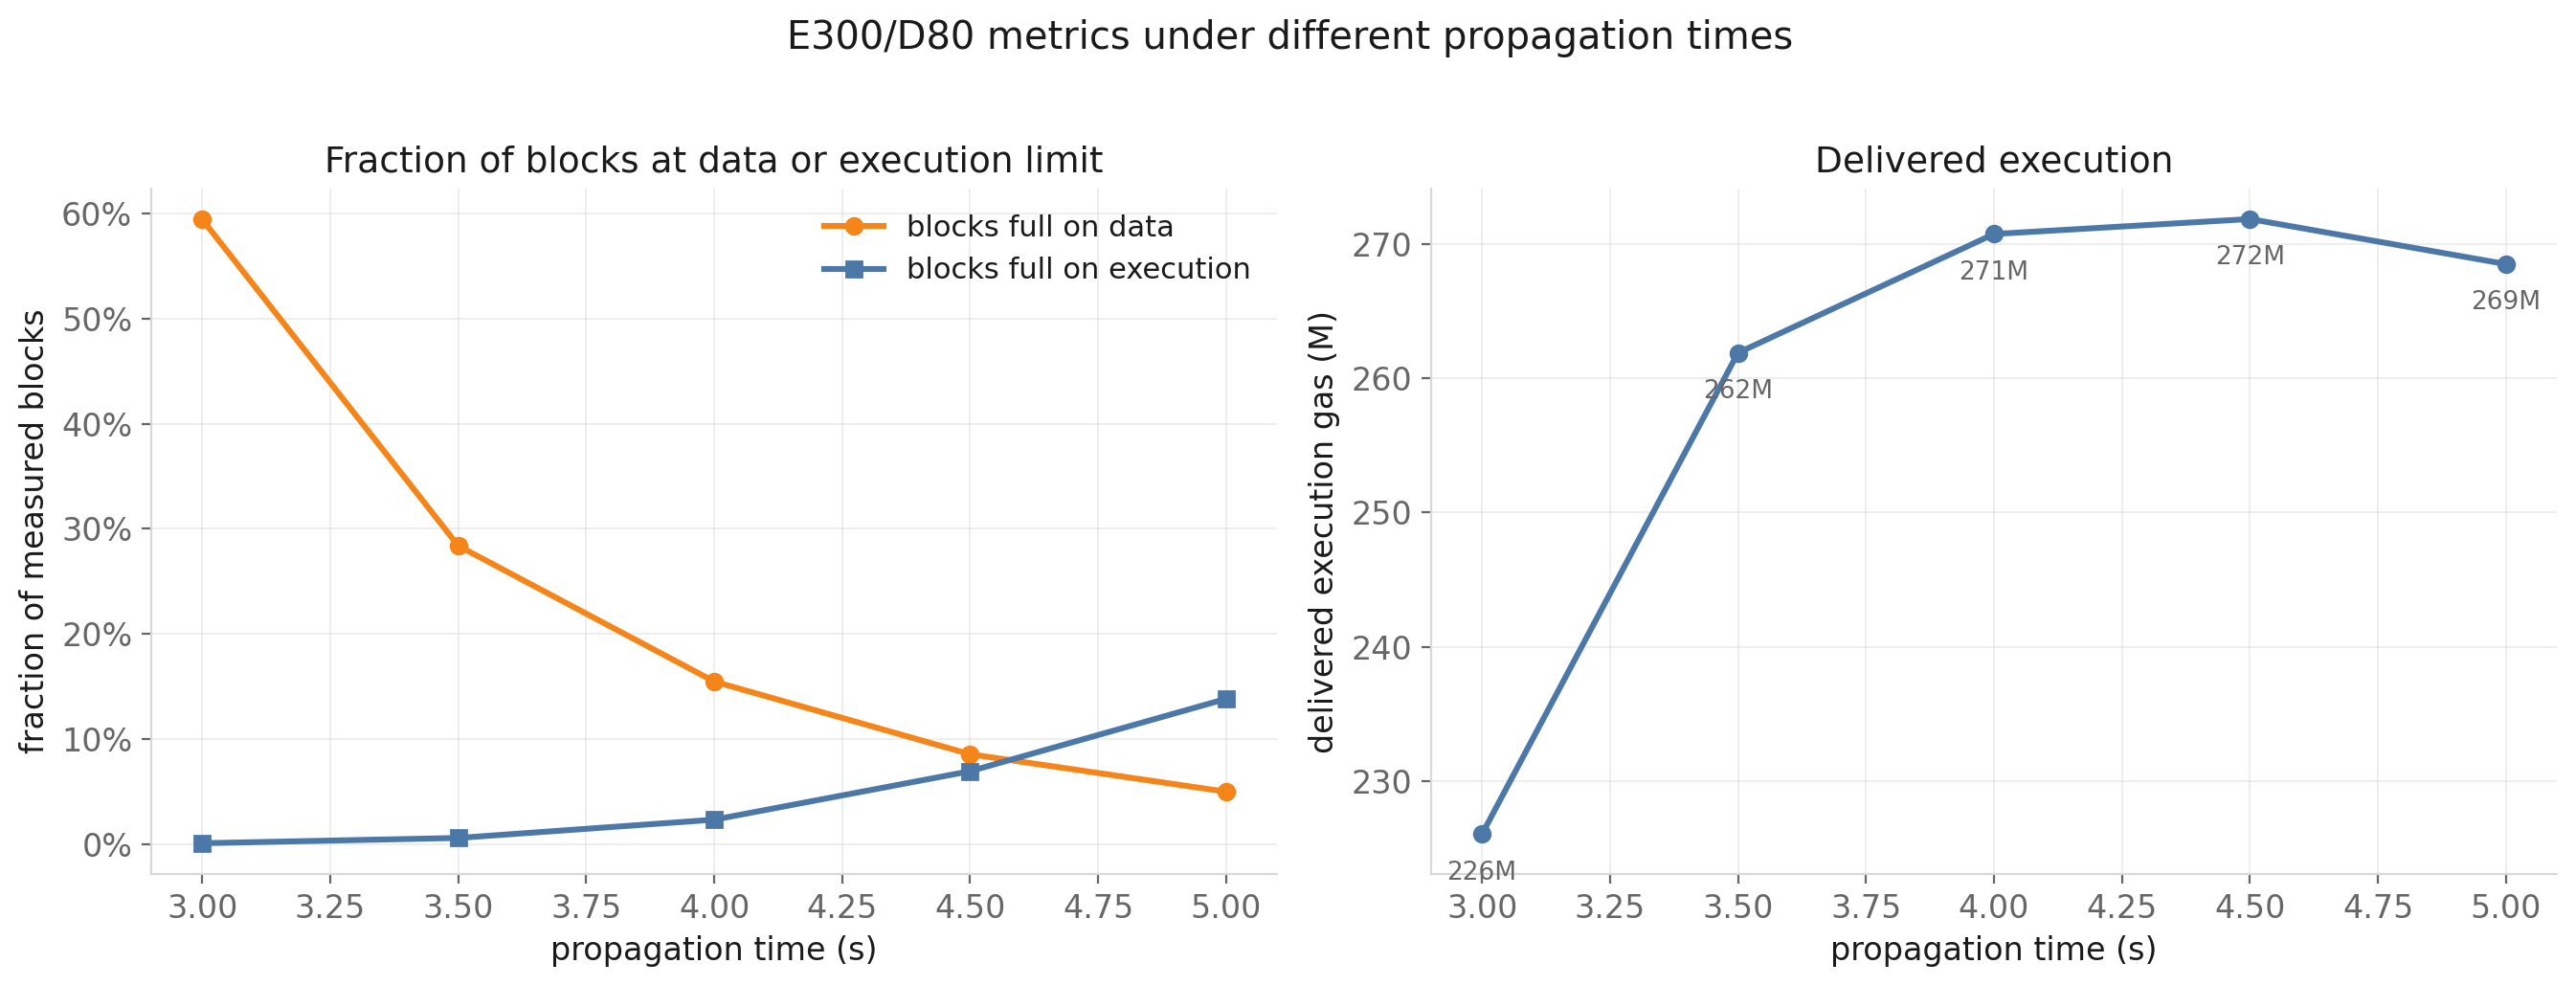

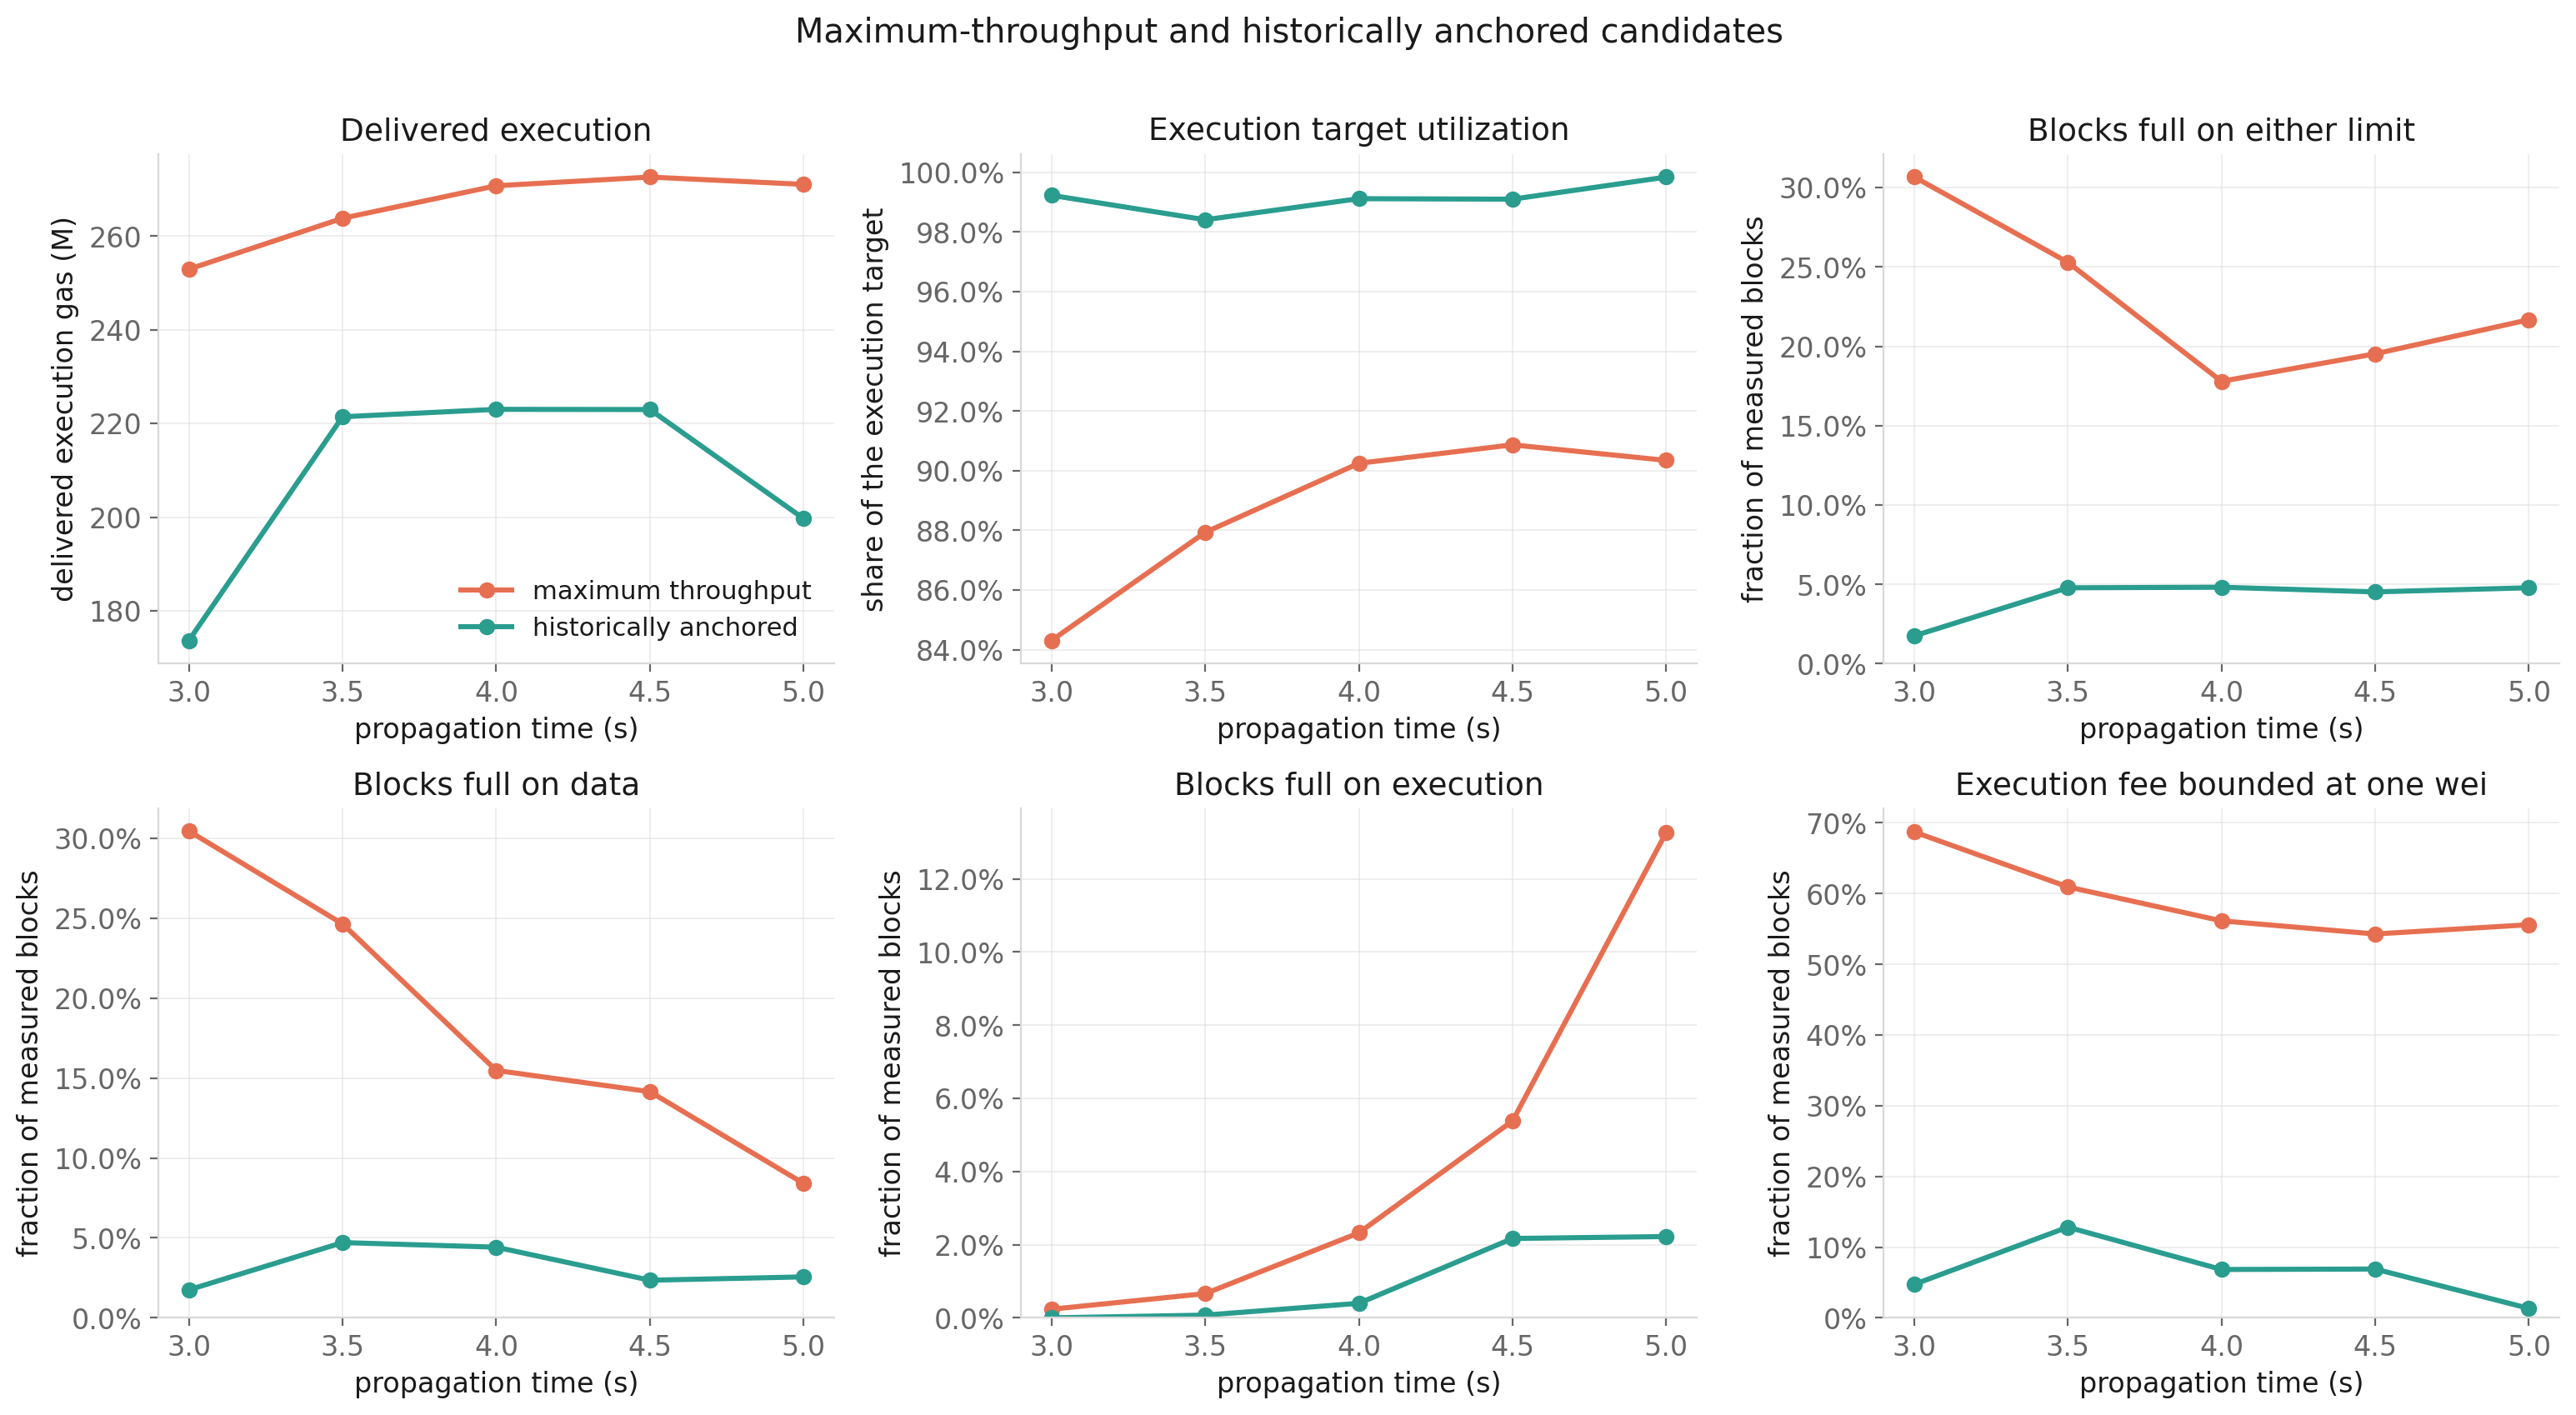

In [4]:
maximum = pd.read_csv(
    OUT_DIR / "slot_time_maximum_throughput.csv"
).sort_values("propagation_time_s")
anchored = pd.read_csv(
    OUT_DIR / "slot_time_historical_benchmark_frontier.csv"
).sort_values("propagation_time_s")

def compact_candidates(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    result["configuration"] = (
        "E" + (result["execution_target"] / 1e6).map(lambda value: f"{value:g}")
        + "/D" + (result["data_target"] / 1e6).map(lambda value: f"{value:g}")
    )
    result["delivered_execution_M"] = result["included_execution"] / 1e6
    return result[[
        "propagation_time_s", "configuration", "delivered_execution_M",
        "execution_floor_bounded_fraction", "any_near_limit_fraction",
    ]]

display(compact_candidates(maximum))
display(compact_candidates(anchored))

import make_slot_time_figures
make_slot_time_figures.main()
display(Image(filename=PLOTS_DIR / "slot_time_substitution.png"))
display(Image(filename=PLOTS_DIR / "slot_time_two_designs.png"))

## Handoff

This notebook writes the full physical slot-time surface, E300/D80 diagnostics, maximum-throughput candidates, historically anchored candidates, and the two slot-time figures used in the report. Notebook 4 reruns the fixed design and target selection under alternative elasticities, BAL allocations, and access-scaling assumptions.